# Final Project — Stock Market Analyzer

## Objective
This notebook analyzes stock-market data in **two parts**:

1. **Part 1 — Single Company Analysis:** explore, prepare, summarize, and visualize one selected company.
2. **Part 2 — Multiple Company Analysis:** download several companies together and compare price performance, returns, volatility, volume, and risk.

> **Note:** The notebook uses `yfinance`, so an internet connection is required when the data-download cells are executed.

> **Charts** are displayed and also saved to the `charts/` folder as PNG files.


## Part 0 — Import Libraries

We use:
- `yfinance` to download market data.
- `pandas` for data manipulation.
- `numpy` for numerical calculations.
- `matplotlib` and `seaborn` for visualization.


In [44]:
# Import the libraries required for the analysis
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Make plots easier to read
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Create folder for saved charts
os.makedirs("charts", exist_ok=True)

print("Libraries imported successfully.")
print("Charts will be saved to the 'charts/' folder.")


Libraries imported successfully.
Charts will be saved to the 'charts/' folder.


## Company List

The following companies are available for analysis. You can add more ticker symbols if required.


In [45]:
# Company reference table
companies_df = pd.DataFrame({
    "Name": [
        "Apple Inc.",
        "NVIDIA Corporation",
        "Microsoft Corporation",
        "Tesla, Inc.",
        "Amazon.com, Inc.",
        "Alphabet Inc. (Google)"
    ],
    "Ticker": ["AAPL", "NVDA", "MSFT", "TSLA", "AMZN", "GOOGL"]
})

display(companies_df)


,Name,Ticker
0,Apple Inc.,AAPL
1,NVIDIA Corporation,NVDA
2,Microsoft Corporation,MSFT
3,"Tesla, Inc.",TSLA
4,"Amazon.com, Inc.",AMZN
5,Alphabet Inc. (Google),GOOGL


# PART 1 — SINGLE COMPANY ANALYSIS

In this section, we:
1. Select one company.
2. Download its historical data.
3. Explore the dataset.
4. Prepare useful date-related columns.
5. Perform numerical analysis.
6. Create several meaningful plots (and save them).


## 1.1 Select Company and Date Range

Change the values below instead of using `input()`. This makes the notebook easier to reproduce and avoids errors caused by invalid input.

**Default values are set for easy re-runs.** Edit them as needed.


In [46]:
# ---------------- SELECT COMPANY & DATES (edit these) ----------------
# For reproducibility we hard-code defaults. Change them as needed.

ticker = "NVDA"          # e.g. AAPL, NVDA, MSFT, TSLA, AMZN, GOOGL
start_date = "2023-01-01"
end_date = "2026-09-01"

valid_tickers = set(companies_df["Ticker"].str.upper())

if ticker.upper() not in valid_tickers:
    raise ValueError(f"Invalid ticker '{ticker}'. Choose from: {', '.join(sorted(valid_tickers))}")

ticker = ticker.upper()
start = pd.to_datetime(start_date)
end = pd.to_datetime(end_date)

if end <= start:
    raise ValueError("End date must be after start date.")

print(f"Selected company: {ticker}")
print(f"Analysis period: {start_date} to {end_date}")
# ---------------------------------------------------------------------


Selected company: NVDA
Analysis period: 2023-01-01 to 2026-09-01


## 1.1b Download Single Company Data

Download historical OHLCV data for the selected ticker.  
yfinance may return MultiIndex columns even for a single ticker — we flatten them.


In [47]:
# Download data for the single company
raw = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

if raw.empty:
    raise ValueError(
        f"No data downloaded for {ticker}. "
        "Check ticker, date range, and internet connection."
    )

# Flatten MultiIndex columns if present (common with recent yfinance)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [col[0] for col in raw.columns]

single_data = raw.copy()
print(f"Downloaded {len(single_data)} rows for {ticker}")
display(single_data.head())


Downloaded 918 rows for NVDA


,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,14.283263,14.962754,14.064749,14.818075,401277000
2023-01-04,14.716300,14.820070,14.209427,14.534704,431324000
2023-01-05,14.233375,14.531711,14.116633,14.458873,389168000
2023-01-06,14.826056,14.976722,14.002886,14.441910,405044000
2023-01-09,15.593352,16.020403,15.107432,15.250115,504231000


## 1.2 Explore the Data

The following checks help us understand the size, structure, data types, missing values, and descriptive statistics of the dataset.


In [48]:
def exploring_data(data):
    """Display basic information about a stock-data DataFrame."""

    print("=" * 90)
    print("DATASET SHAPE")
    print("=" * 90)
    print(f"Rows: {data.shape[0]:,}")
    print(f"Columns: {data.shape[1]}")

    print("\n" + "=" * 90)
    print("FIRST 5 ROWS")
    print("=" * 90)
    display(data.head())

    print("=" * 90)
    print("DATA TYPES AND NON-NULL COUNTS")
    print("=" * 90)
    data.info()

    print("\n" + "=" * 90)
    print("MISSING VALUES")
    print("=" * 90)
    display(data.isnull().sum().to_frame("Missing Values"))

    print("=" * 90)
    print("DESCRIPTIVE STATISTICS")
    print("=" * 90)
    display(data.describe().T)

    return

exploring_data(single_data)


DATASET SHAPE
Rows: 918
Columns: 5

FIRST 5 ROWS


,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,14.283263,14.962754,14.064749,14.818075,401277000
2023-01-04,14.716300,14.820070,14.209427,14.534704,431324000
2023-01-05,14.233375,14.531711,14.116633,14.458873,389168000
2023-01-06,14.826056,14.976722,14.002886,14.441910,405044000
2023-01-09,15.593352,16.020403,15.107432,15.250115,504231000


DATA TYPES AND NON-NULL COUNTS
<class 'pandas.DataFrame'>
DatetimeIndex: 918 entries, 2023-01-03 to 2026-08-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   918 non-null    float64
 1   High    918 non-null    float64
 2   Low     918 non-null    float64
 3   Open    918 non-null    float64
 4   Volume  918 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 43.0 KB

MISSING VALUES


,Missing Values
Close,0
High,0
Low,0
Open,0
Volume,0


DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Close,918.0,1.172448e+02,6.224689e+01,1.423337e+01,4.824980e+01,1.224282e+02,1.778281e+02,2.354656e+02
High,918.0,1.191411e+02,6.314851e+01,1.453171e+01,4.899115e+01,1.243700e+02,1.800278e+02,2.362646e+02
Low,918.0,1.152183e+02,6.140987e+01,1.400289e+01,4.761492e+01,1.188829e+02,1.752516e+02,2.290331e+02
Open,918.0,1.172910e+02,6.238029e+01,1.444191e+01,4.831580e+01,1.216944e+02,1.777754e+02,2.296024e+02
Volume,918.0,3.214679e+08,1.778766e+08,6.552850e+07,1.788739e+08,2.847892e+08,4.273278e+08,1.543911e+09


## 1.3 Data Preparation

We convert the index into a normal `Date` column and create:
- `Year`
- `Month`
- `Day`
- `Daily Return`
- `Price Change`

These columns make time-based analysis easier.


In [49]:
def data_preparation(data):
    """Prepare stock data for analysis and visualization."""

    data = data.copy()

    # Convert the DatetimeIndex into a normal column
    data = data.reset_index()
    # Ensure the date column is named 'Date'
    if "Date" not in data.columns and "index" in data.columns:
        data = data.rename(columns={"index": "Date"})
    data["Date"] = pd.to_datetime(data["Date"])

    # Create date-related features
    data["Year"] = data["Date"].dt.year
    data["Month"] = data["Date"].dt.month_name()
    data["Day"] = data["Date"].dt.day_name()

    # Calculate daily percentage return from the closing price
    data["Daily Return"] = data["Close"].pct_change() * 100

    # Calculate the absolute daily price change
    data["Price Change"] = data["Close"].diff()

    return data

single_data = data_preparation(single_data)

display(single_data.head())


,Date,Close,High,Low,Open,Volume,Year,Month,Day,Daily Return,Price Change
0,2023-01-03,14.283263,14.962754,14.064749,14.818075,401277000,2023,January,Tuesday,NaN,NaN
1,2023-01-04,14.716300,14.820070,14.209427,14.534704,431324000,2023,January,Wednesday,3.031778,0.433037
2,2023-01-05,14.233375,14.531711,14.116633,14.458873,389168000,2023,January,Thursday,-3.281568,-0.482925
3,2023-01-06,14.826056,14.976722,14.002886,14.441910,405044000,2023,January,Friday,4.164029,0.592682
4,2023-01-09,15.593352,16.020403,15.107432,15.250115,504231000,2023,January,Monday,5.175320,0.767296


## 1.4 Numerical Analysis

The next function calculates important statistics for:
- Opening price
- Closing price
- Highest and lowest prices
- Trading volume
- Average daily return
- Volatility

Volatility is measured as the standard deviation of daily returns.


In [50]:
def num_analysis(data):
    """Return important numerical statistics for one company."""

    stats = {
        "Average Open": data["Open"].mean(),
        "Average Close": data["Close"].mean(),
        "Maximum Close": data["Close"].max(),
        "Minimum Close": data["Close"].min(),
        "Maximum High": data["High"].max(),
        "Minimum Low": data["Low"].min(),
        "Average Volume": data["Volume"].mean(),
        "Maximum Volume": data["Volume"].max(),
        "Average Daily Return (%)": data["Daily Return"].mean(),
        "Daily Return Volatility (%)": data["Daily Return"].std(),
    }

    return pd.Series(stats).round(2)

single_stats = num_analysis(single_data)
display(single_stats.to_frame("Value"))


,Value
Average Open,1.172900e+02
Average Close,1.172400e+02
Maximum Close,2.354700e+02
Minimum Close,1.423000e+01
Maximum High,2.362600e+02
Minimum Low,1.400000e+01
Average Volume,3.214679e+08
Maximum Volume,1.543911e+09
Average Daily Return (%),3.400000e-01
Daily Return Volatility (%),3.050000e+00


## 1.5 Year-wise Analysis

Instead of summing stock prices across a year (which is not a meaningful price statistic), we use:
- First closing price of the year
- Last closing price of the year
- Yearly return
- Average volume

This gives a more meaningful view of annual performance.


In [51]:
# Create yearly summary statistics
yearly_summary = (
    single_data.set_index("Date")
    .resample("YE")
    .agg(
        Start_Close=("Close", "first"),
        End_Close=("Close", "last"),
        Average_Close=("Close", "mean"),
        Average_Volume=("Volume", "mean")
    )
)

yearly_summary["Yearly Return (%)"] = (
    (yearly_summary["End_Close"] / yearly_summary["Start_Close"]) - 1
) * 100

yearly_summary.index = yearly_summary.index.year

display(yearly_summary.round(2))


,Start_Close,End_Close,Average_Close,Average_Volume,Yearly Return (%)
Date,,,,,
2023,14.28,49.43,36.50,4.735575e+08,246.10
2024,48.08,134.09,107.65,3.771891e+08,178.87
2025,138.10,186.27,153.70,2.207510e+08,34.88
2026,188.62,220.78,198.52,1.595105e+08,17.05


## 1.6 Single Company Visualizations

The following plots show different aspects of the selected company's behavior:

1. Closing-price trend over time.
2. Trading volume over time.
3. Daily-return distribution.
4. Yearly return.
5. Moving averages to observe the broader trend.

All charts are saved as PNG files in the `charts/` folder.


In [52]:
# Create moving averages for trend analysis
single_data["MA20"] = single_data["Close"].rolling(20).mean()
single_data["MA50"] = single_data["Close"].rolling(50).mean()

# Helper to save + show each figure
def save_and_show(fig, filename):
    path = os.path.join("charts", filename)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()
    plt.close(fig)

Saved: charts/NVDA_closing_price.png


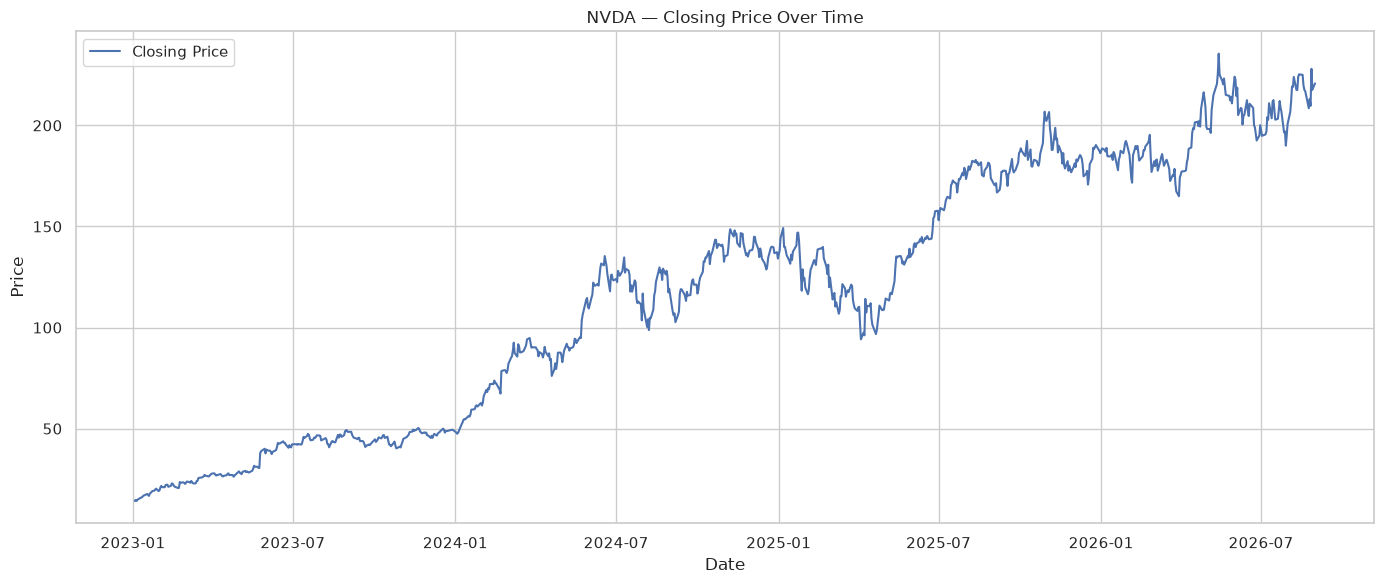

In [53]:
# Plot 1: Closing price
fig1, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(single_data["Date"], single_data["Close"], label="Closing Price")
ax1.set_title(f"{ticker} — Closing Price Over Time")
ax1.set_xlabel("Date")
ax1.set_ylabel("Price")
ax1.legend()
fig1.tight_layout()
save_and_show(fig1, f"{ticker}_closing_price.png")

Saved: charts/NVDA_volume.png


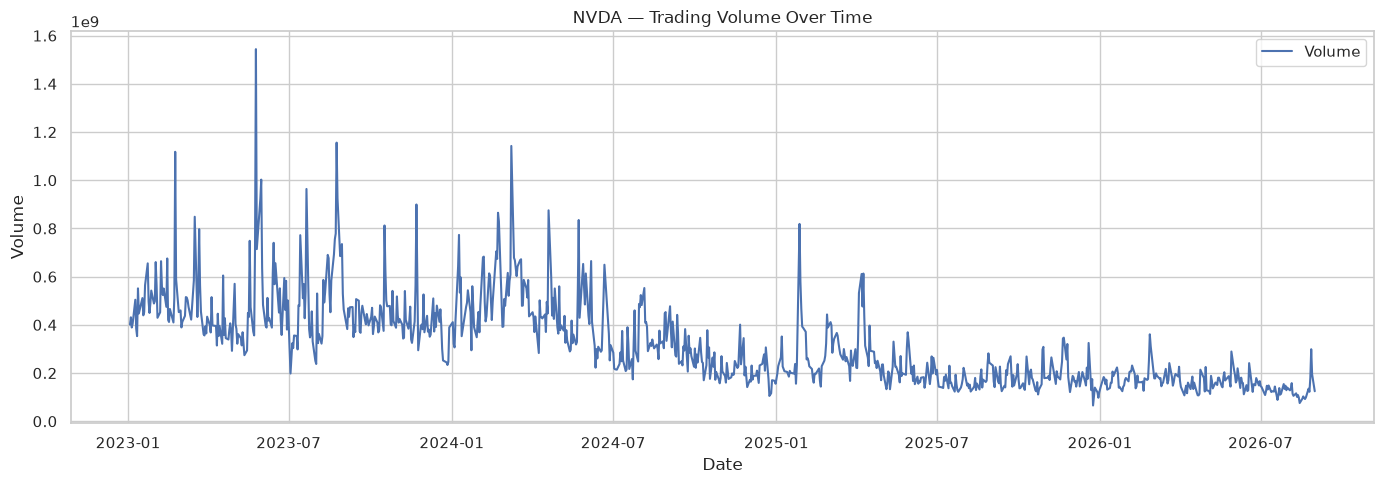

In [54]:
# Plot 2: Trading volume
fig2, ax2 = plt.subplots(figsize=(14, 5))
ax2.plot(single_data["Date"], single_data["Volume"], label="Volume")
ax2.set_title(f"{ticker} — Trading Volume Over Time")
ax2.set_xlabel("Date")
ax2.set_ylabel("Volume")
ax2.legend()
fig2.tight_layout()
save_and_show(fig2, f"{ticker}_volume.png")

Saved: charts/NVDA_daily_return_dist.png


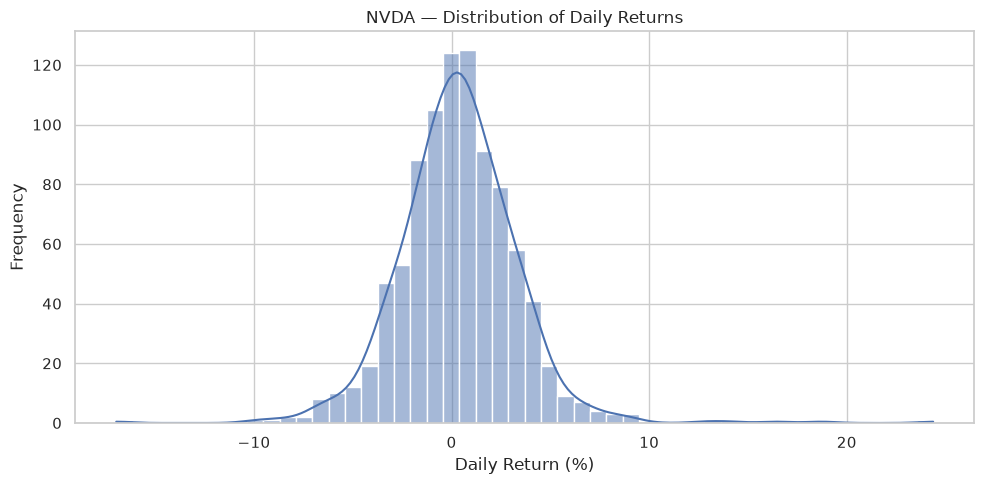

In [55]:
# Plot 3: Daily return distribution
fig3, ax3 = plt.subplots(figsize=(10, 5))
sns.histplot(single_data["Daily Return"].dropna(), bins=50, kde=True, ax=ax3)
ax3.set_title(f"{ticker} — Distribution of Daily Returns")
ax3.set_xlabel("Daily Return (%)")
ax3.set_ylabel("Frequency")
fig3.tight_layout()
save_and_show(fig3, f"{ticker}_daily_return_dist.png")

Saved: charts/NVDA_yearly_returns.png


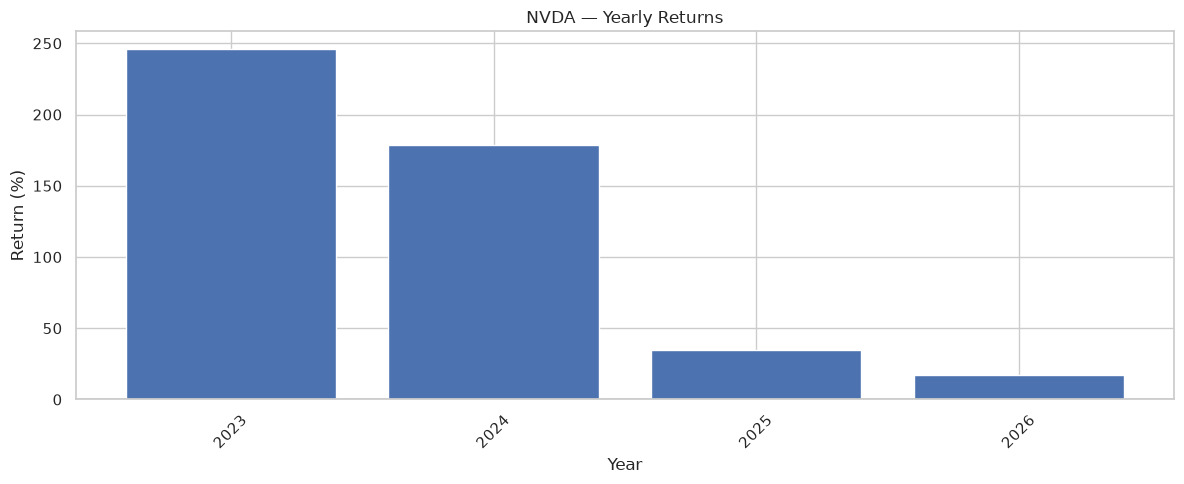

In [56]:
# Plot 4: Yearly return
fig4, ax4 = plt.subplots(figsize=(12, 5))
ax4.bar(yearly_summary.index.astype(str), yearly_summary["Yearly Return (%)"])
ax4.axhline(0, linewidth=1)
ax4.set_title(f"{ticker} — Yearly Returns")
ax4.set_xlabel("Year")
ax4.set_ylabel("Return (%)")
plt.setp(ax4.get_xticklabels(), rotation=45)
fig4.tight_layout()
save_and_show(fig4, f"{ticker}_yearly_returns.png")

Saved: charts/NVDA_moving_averages.png


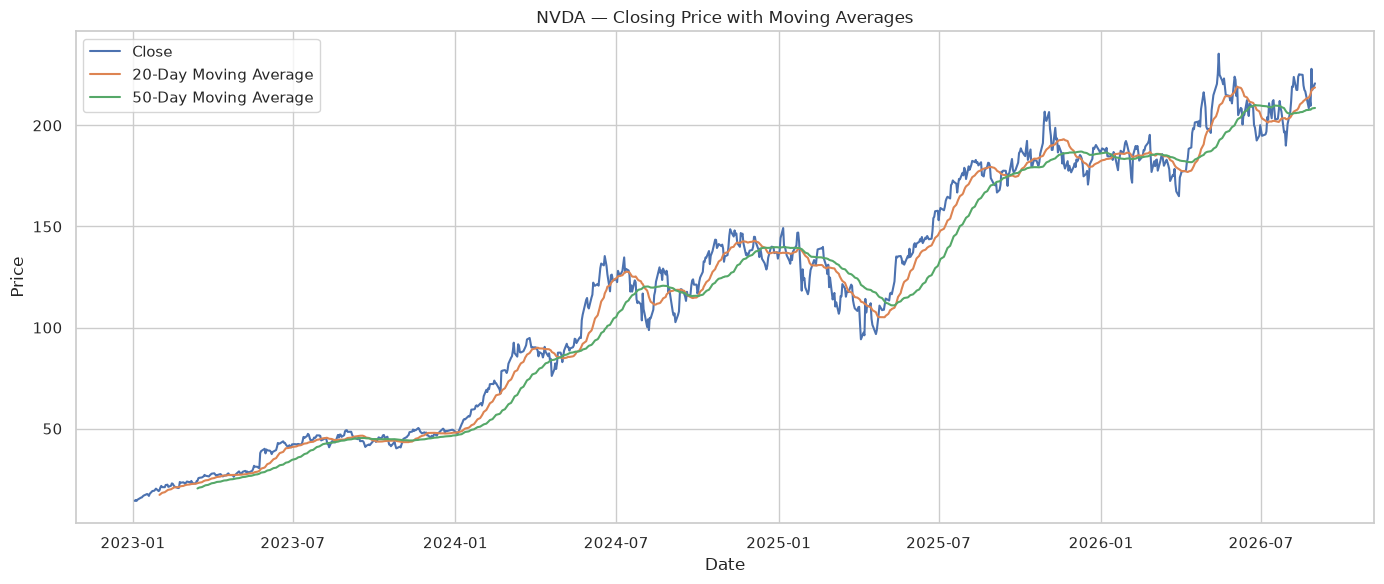

In [57]:
# Plot 5: Moving averages
fig5, ax5 = plt.subplots(figsize=(14, 6))
ax5.plot(single_data["Date"], single_data["Close"], label="Close")
ax5.plot(single_data["Date"], single_data["MA20"], label="20-Day Moving Average")
ax5.plot(single_data["Date"], single_data["MA50"], label="50-Day Moving Average")
ax5.set_title(f"{ticker} — Closing Price with Moving Averages")
ax5.set_xlabel("Date")
ax5.set_ylabel("Price")
ax5.legend()
fig5.tight_layout()
save_and_show(fig5, f"{ticker}_moving_averages.png")

## 1.7 Key Findings for the Selected Company

The following cell automatically reports the strongest and weakest yearly performance and the most active trading day.


In [58]:
best_year = yearly_summary["Yearly Return (%)"].idxmax()
worst_year = yearly_summary["Yearly Return (%)"].idxmin()
highest_volume_date = single_data.loc[single_data["Volume"].idxmax(), "Date"]

print(f"Company: {ticker}")
print(f"Best yearly return: {best_year} ({yearly_summary.loc[best_year, 'Yearly Return (%)']:.2f}%)")
print(f"Worst yearly return: {worst_year} ({yearly_summary.loc[worst_year, 'Yearly Return (%)']:.2f}%)")
print(f"Highest-volume trading date: {highest_volume_date.date()}")
print(f"Daily return volatility: {single_data['Daily Return'].std():.2f}%")


Company: NVDA
Best yearly return: 2023 (246.10%)
Worst yearly return: 2026 (17.05%)
Highest-volume trading date: 2023-05-25
Daily return volatility: 3.05%


# PART 2 — MULTIPLE COMPANY ANALYSIS

This section compares multiple companies over the **same date range**.

### Metrics compared
- Closing-price performance
- Normalized growth from a common starting point
- Average daily return
- Volatility
- Total return
- Average trading volume
- Correlation between company returns

Normalization is important because companies have very different share prices. A stock priced at $500 cannot be fairly compared with one priced at $100 simply by looking at the raw price.


In [59]:
# ---------------- MULTIPLE COMPANY SELECTION (edit these) ----------------
# Default comparison set for reproducibility. Change as needed.

comparison_tickers = ["AAPL", "NVDA", "MSFT", "TSLA"]

# Validate
comparison_tickers = list(dict.fromkeys([t.upper().strip() for t in comparison_tickers]))

if len(comparison_tickers) < 2:
    raise ValueError("Please select at least two different companies.")

invalid = [t for t in comparison_tickers if t not in valid_tickers]
if invalid:
    raise ValueError(f"Invalid ticker(s): {', '.join(invalid)}. Available: {', '.join(sorted(valid_tickers))}")

print("Companies selected for comparison:")
display(companies_df[companies_df["Ticker"].isin(comparison_tickers)])
# -------------------------------------------------------------------------


Companies selected for comparison:


,Name,Ticker
0,Apple Inc.,AAPL
1,NVIDIA Corporation,NVDA
2,Microsoft Corporation,MSFT
3,"Tesla, Inc.",TSLA


## 2.1 Download Multiple Companies

We download all selected tickers over the same period so that their performance can be compared consistently.


In [60]:
# Download adjusted closing prices and volume for all selected companies
multi_data = yf.download(
    comparison_tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

if multi_data.empty:
    raise ValueError("No multi-company data was downloaded. Check the tickers, dates, and internet connection.")

# With multiple tickers, yfinance normally returns MultiIndex columns.
# We extract Close and Volume separately.
if isinstance(multi_data.columns, pd.MultiIndex):
    close_prices = multi_data["Close"].copy()
    volumes = multi_data["Volume"].copy()
else:
    # Fallback for the unlikely case of a single-level result.
    close_prices = multi_data[["Close"]].copy()
    volumes = multi_data[["Volume"]].copy()

# Remove rows where all companies are missing
close_prices = close_prices.dropna(how="all")
volumes = volumes.reindex(close_prices.index)

print(f"Downloaded data shape (Close): {close_prices.shape}")
display(close_prices.head())


Downloaded data shape (Close): (918, 4)


Ticker,AAPL,MSFT,NVDA,TSLA
Date,,,,
2023-01-03,122.876747,232.510574,14.283263,108.099998
2023-01-04,124.144135,222.339813,14.716300,113.639999
2023-01-05,122.827629,215.750153,14.233375,110.339996
2023-01-06,127.346970,218.292816,14.826056,113.059998
2023-01-09,127.867645,220.418228,15.593352,119.769997


## 2.2 Normalize Prices for a Fair Comparison

Every company is set to **100 on the first available trading day**.

For example:
- 150 means the investment grew by 50% from the starting point.
- 80 means the investment fell by 20%.

This allows companies with different share prices to be compared on the same scale.


Saved: charts/multi_normalized_performance.png


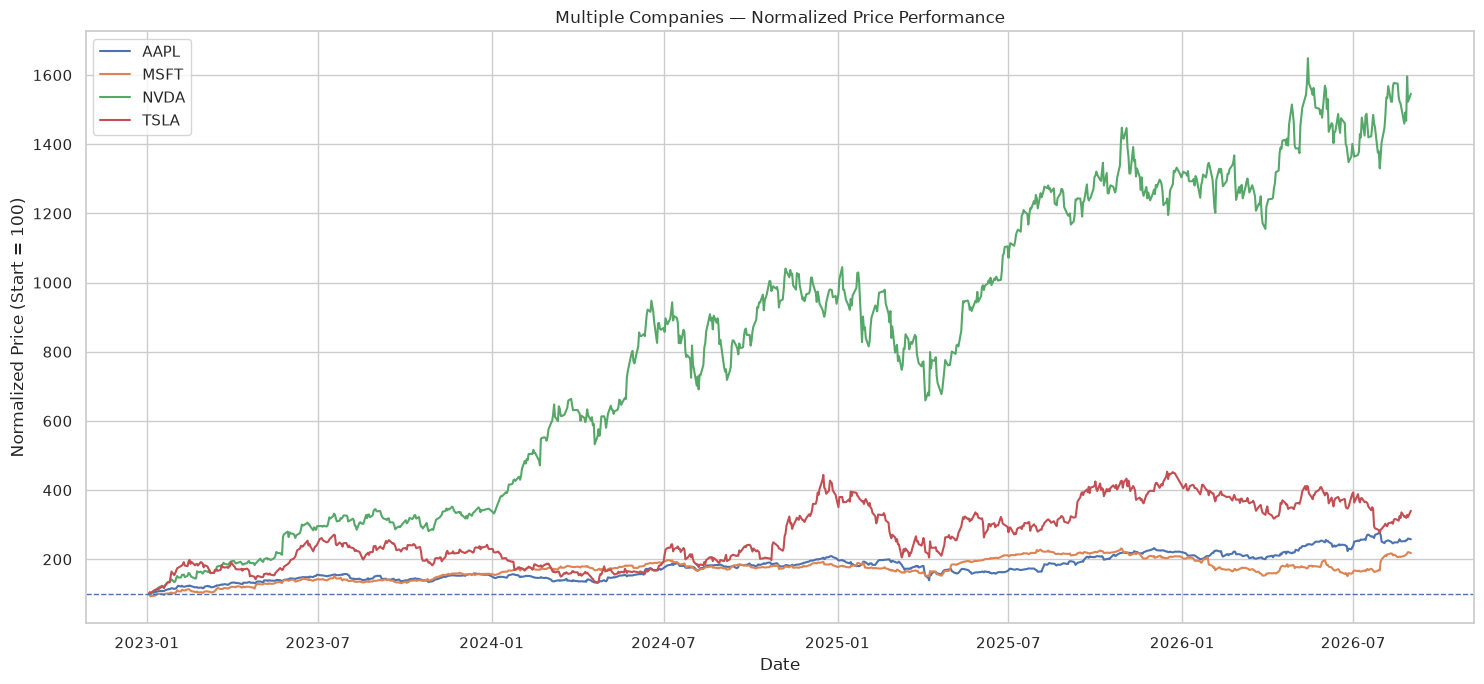

In [61]:
# Forward-fill small gaps caused by different trading calendars,
# then remove rows that still do not contain any company data.
close_prices = close_prices.ffill().dropna(how="all")

# Normalize every company's first available price to 100
normalized_prices = close_prices.div(close_prices.bfill().iloc[0]) * 100

# Plot normalized performance
fig, ax = plt.subplots(figsize=(15, 7))

for company in normalized_prices.columns:
    ax.plot(normalized_prices.index, normalized_prices[company], label=company)

ax.axhline(100, linewidth=1, linestyle="--")
ax.set_title("Multiple Companies — Normalized Price Performance")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Price (Start = 100)")
ax.legend()
fig.tight_layout()
save_and_show(fig, "multi_normalized_performance.png")


## 2.3 Calculate Returns and Risk

For each company we calculate:
- **Total Return:** overall percentage change during the selected period.
- **Average Daily Return:** mean daily percentage return.
- **Volatility:** standard deviation of daily returns.
- **Average Volume:** average number of shares traded per day.

Higher return is not automatically better because it may come with higher volatility.


In [62]:
# Daily percentage returns
returns = close_prices.pct_change() * 100

comparison_summary = pd.DataFrame({
    "Total Return (%)": ((close_prices.iloc[-1] / close_prices.bfill().iloc[0]) - 1) * 100,
    "Average Daily Return (%)": returns.mean(),
    "Volatility (%)": returns.std(),
    "Average Volume": volumes.mean()
})

comparison_summary = comparison_summary.sort_values(
    "Total Return (%)",
    ascending=False
)

display(comparison_summary.round(2))


,Total Return (%),Average Daily Return (%),Volatility (%),Average Volume
Ticker,,,,
NVDA,1445.73,0.34,3.05,3.214679e+08
TSLA,240.38,0.20,3.64,9.973090e+07
AAPL,157.86,0.12,1.63,5.562198e+07
MSFT,118.18,0.10,1.66,2.585045e+07


## 2.4 Compare Total Returns

This chart ranks the companies by their total price return over the selected period.


Saved: charts/multi_total_returns.png


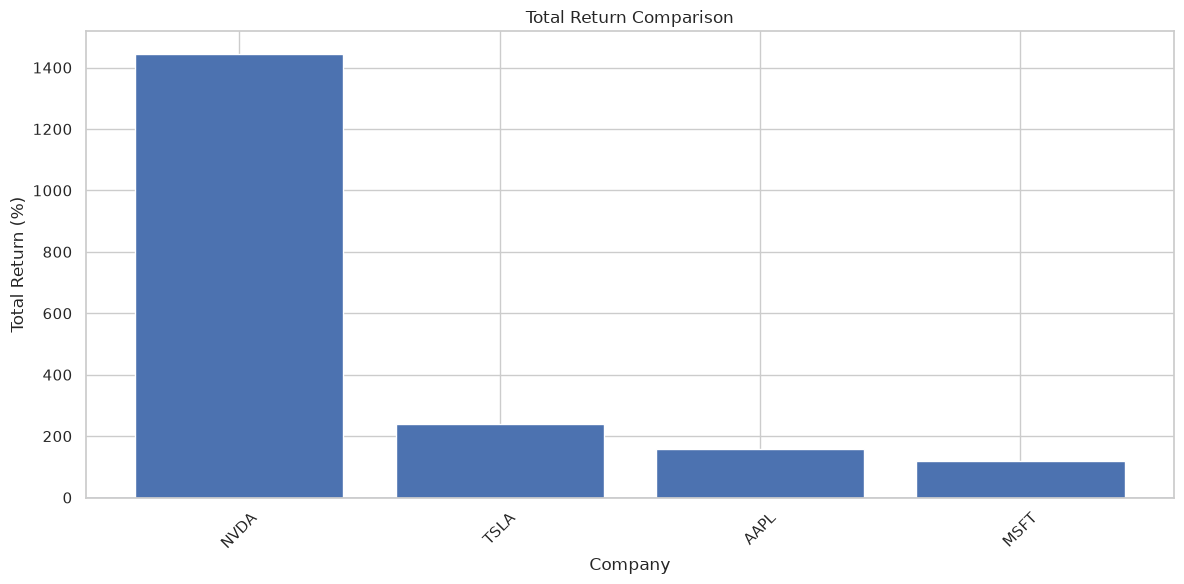

In [63]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    comparison_summary.index,
    comparison_summary["Total Return (%)"]
)
ax.axhline(0, linewidth=1)
ax.set_title("Total Return Comparison")
ax.set_xlabel("Company")
ax.set_ylabel("Total Return (%)")
plt.setp(ax.get_xticklabels(), rotation=45)
fig.tight_layout()
save_and_show(fig, "multi_total_returns.png")


## 2.5 Compare Volatility

Volatility measures how widely daily returns fluctuate.

- Lower volatility generally means more stable daily movement.
- Higher volatility means larger day-to-day price movements.

Volatility alone should not be used to decide which company is better; it should be considered together with return.


Saved: charts/multi_volatility.png


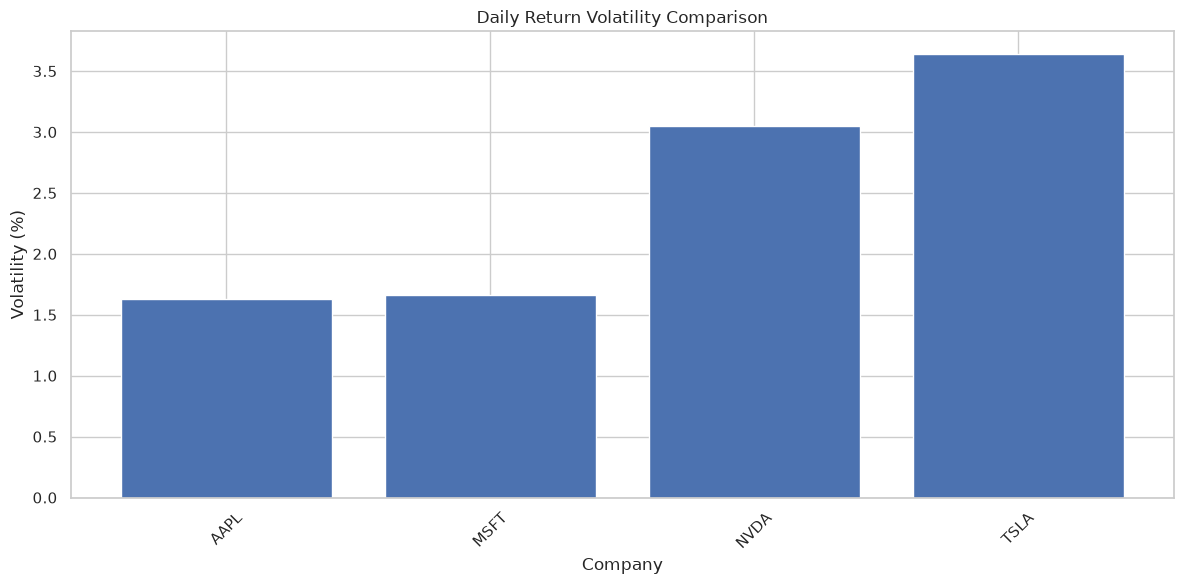

In [64]:
volatility_rank = comparison_summary.sort_values("Volatility (%)")

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    volatility_rank.index,
    volatility_rank["Volatility (%)"]
)
ax.set_title("Daily Return Volatility Comparison")
ax.set_xlabel("Company")
ax.set_ylabel("Volatility (%)")
plt.setp(ax.get_xticklabels(), rotation=45)
fig.tight_layout()
save_and_show(fig, "multi_volatility.png")


## 2.6 Compare Average Trading Volume

Trading volume indicates how many shares are traded on average each day.


Saved: charts/multi_volume.png


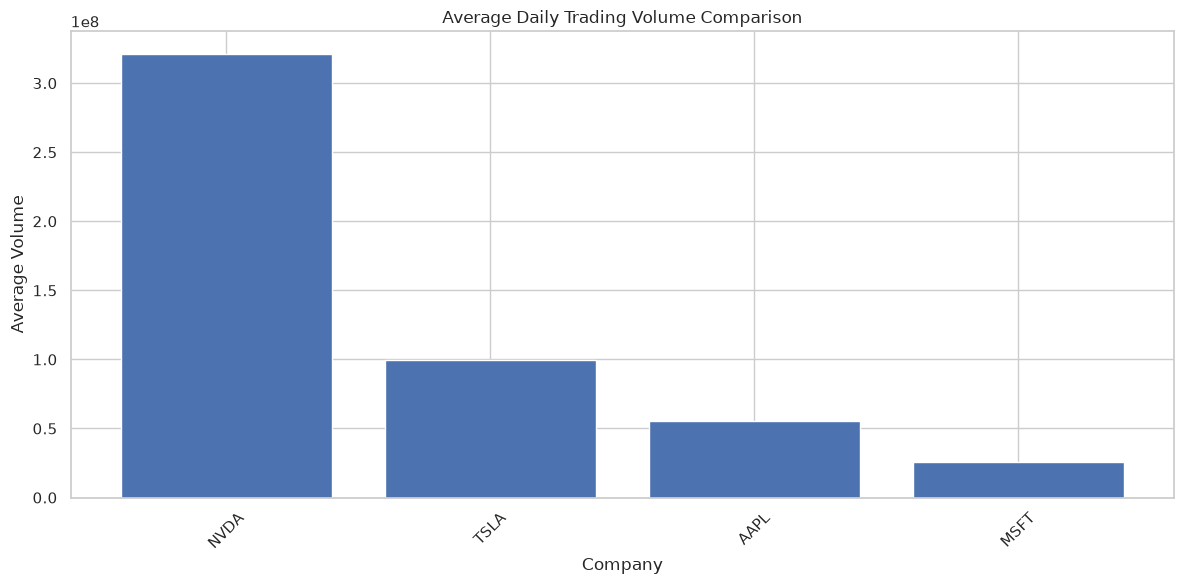

In [65]:
volume_rank = comparison_summary.sort_values("Average Volume", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    volume_rank.index,
    volume_rank["Average Volume"]
)
ax.set_title("Average Daily Trading Volume Comparison")
ax.set_xlabel("Company")
ax.set_ylabel("Average Volume")
plt.setp(ax.get_xticklabels(), rotation=45)
fig.tight_layout()
save_and_show(fig, "multi_volume.png")


## 2.7 Correlation Between Companies

The correlation matrix shows how similarly companies' **daily returns** move.

- Close to `+1`: strong positive relationship.
- Close to `0`: weak linear relationship.
- Close to `-1`: strong negative relationship.

This is more useful than correlating raw stock prices because returns remove much of the effect of different price scales.


Saved: charts/multi_correlation_heatmap.png


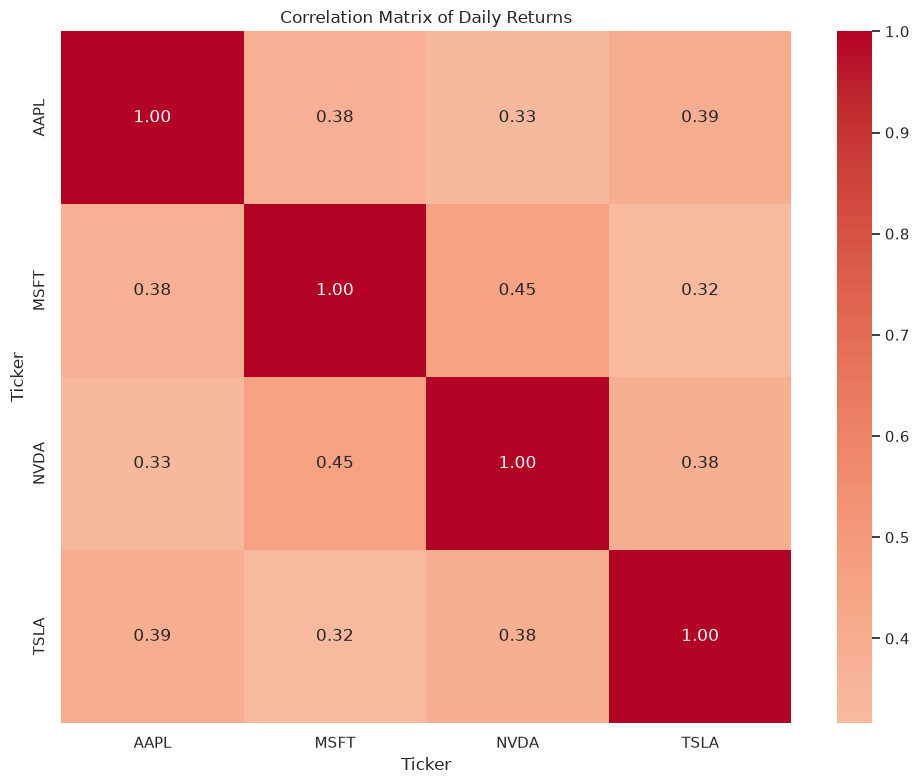

In [66]:
# Calculate correlation between daily returns
return_correlation = returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    return_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax
)
ax.set_title("Correlation Matrix of Daily Returns")
fig.tight_layout()
save_and_show(fig, "multi_correlation_heatmap.png")


## 2.8 Risk–Return Comparison

A useful way to compare companies is to plot:

- **X-axis:** volatility (risk)
- **Y-axis:** total return (performance)

A company farther upward has a higher total return, while a company farther right has higher volatility.


Saved: charts/multi_risk_return.png


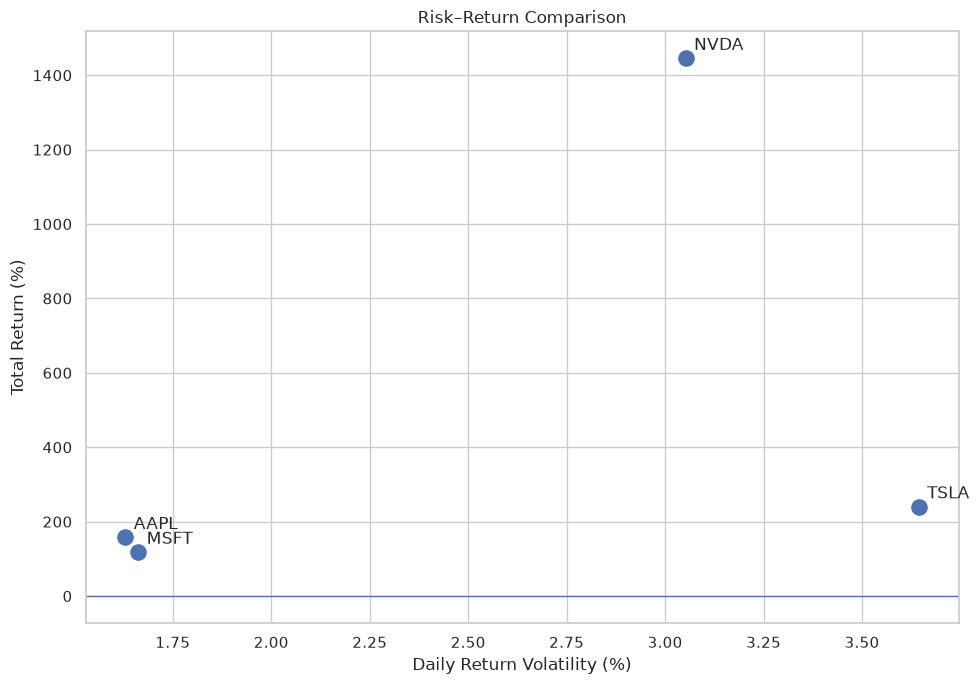

In [67]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    comparison_summary["Volatility (%)"],
    comparison_summary["Total Return (%)"],
    s=120
)

for company, row in comparison_summary.iterrows():
    ax.annotate(
        company,
        (row["Volatility (%)"], row["Total Return (%)"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

ax.axhline(0, linewidth=1)
ax.set_title("Risk–Return Comparison")
ax.set_xlabel("Daily Return Volatility (%)")
ax.set_ylabel("Total Return (%)")
fig.tight_layout()
save_and_show(fig, "multi_risk_return.png")


# Final Summary

## Single Company Analysis
The first part examined one selected company in detail using:
- Dataset exploration
- Data preparation
- Descriptive statistics
- Year-wise performance
- Price and volume trends
- Daily-return distribution
- Moving averages

## Multiple Company Analysis
The second part compared several companies using:
- Normalized price performance
- Total return
- Average daily return
- Volatility
- Average trading volume
- Return correlation
- Risk–return relationship

### Important Interpretation
A good stock comparison should not rely on only one metric. **Return, volatility, trading activity, and correlation should be considered together.** The results also depend strongly on the selected time period.

### Saved Charts
All charts have been saved as PNG files in the `charts/` directory.
